In [1]:
!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 706.0 kB/s eta 0:00:00 0:00:01
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.4 MB/s eta 0:00:00
  Using cached charset_normalizer-3.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (45 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 3.6 MB/s eta 0:00:0000:0100:01
Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (807 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 9.3 MB/s eta 0:00:00
Using cached cer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision as tv
import torch

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_505e2718078abace12d1a1a8b43f2413 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('airbus-ship-detection')

print("Path to competition files:", path)

  0%|          | 100M/28.6G [00:09<43:45, 11.7MB/s]   

In [2]:
import os
from pathlib import Path
import glob
import pandas as pd

In [3]:
from PIL import Image
import re
import cv2

In [4]:
train_path = './train_v2/'
train_markup = 'train_ship_segmentations_v2.csv'

In [5]:
train_exts = []
train_files = []

In [6]:
for root, dirs, files in os.walk(train_path):
      print(root)
      for file in files:
            path = Path(file)
            train_files.append(str(path))
            train_exts.append(path.suffix)  

./train_v2/


In [7]:
np.unique(train_exts), train_files[:5], len(train_files)

(array(['.jpg'], dtype='<U4'),
 ['00003e153.jpg',
  '0001124c7.jpg',
  '000155de5.jpg',
  '000194a2d.jpg',
  '0001b1832.jpg'],
 192556)

### All photos are in jpg format

In [8]:
markup = pd.read_csv(train_markup)

In [9]:
markup.head

<bound method NDFrame.head of               ImageId                                      EncodedPixels
0       00003e153.jpg                                                NaN
1       0001124c7.jpg                                                NaN
2       000155de5.jpg  264661 17 265429 33 266197 33 266965 33 267733...
3       000194a2d.jpg  360486 1 361252 4 362019 5 362785 8 363552 10 ...
4       000194a2d.jpg  51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...
...               ...                                                ...
231718  fffedbb6b.jpg                                                NaN
231719  ffff2aa57.jpg                                                NaN
231720  ffff6e525.jpg                                                NaN
231721  ffffc50b4.jpg                                                NaN
231722  ffffe97f3.jpg                                                NaN

[231723 rows x 2 columns]>

In [10]:
set(markup.ImageId.values).difference(set(train_files))

set()

In [11]:
set(train_files).difference(set(markup.ImageId.values))

set()

### All train samples have labels

In [12]:
na_filt = markup.EncodedPixels.isna()

In [13]:
negative_samples_ind = markup[na_filt].ImageId.index
positive_samples_ind = np.asarray(list(set(markup.ImageId.index).difference(set(markup[na_filt].ImageId.index))))

In [14]:
negative_samples_ind.shape, positive_samples_ind.shape

((150000,), (81723,))

[]

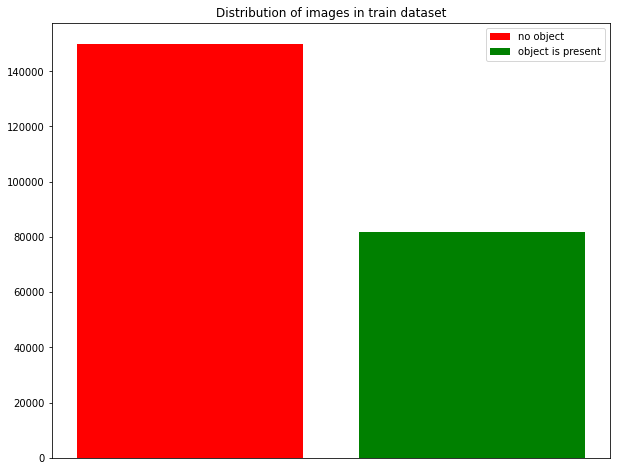

In [15]:
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(x = [0],label= 'no object', height = [negative_samples_ind.shape[0]], color=['red'])
ax.bar(x = [ 1],label= 'object is present', height = [positive_samples_ind.shape[0]], color=['green'])

ax.set_title('Distribution of images in train dataset')
ax.legend()
ax.get_xaxis().set_ticks([])

In [16]:
rand_ind = positive_samples_ind[0]

In [17]:
filename = markup.iloc[rand_ind].ImageId
pixels = markup.iloc[rand_ind].EncodedPixels

In [18]:
filename

'000155de5.jpg'

In [19]:
randimage = Image.open(os.path.join(train_path, filename))
ra = np.asarray(randimage)

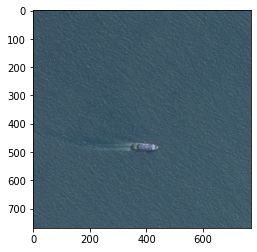

In [20]:
plt.imshow(randimage)

In [21]:
ra.shape, 768**2

((768, 768, 3), 589824)

In [22]:
li = pixels.split(' ')

In [23]:
coord_intens = [(int(li[i]), int(li[i+1])) for i in range(0, len(li)-1, 2)]

In [24]:
mask = np.zeros(ra.shape[:-1:])
masks = np.zeros((len(coord_intens), *mask.shape))
points = []
points_x = []
prev_x = 0
prev_y = 0
prev_intens = 0
for i, (coord, intens) in enumerate(coord_intens):
    y = coord//ra.shape[0]
    x = coord%ra.shape[0]
    points.append((x, y))
    mask[x:x+intens, y:y+intens] = 1
    masks[i, x:x+intens, y:y+intens] = 1
    
    #print(x, x+intens, y, y+intens)

In [25]:
masks.shape

(104, 768, 768)

In [26]:
(masks[0]==masks[1]).all()

False

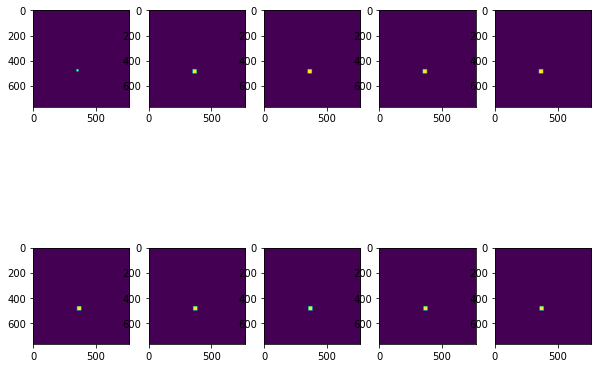

In [27]:
fig, axs = plt.subplots(2, 5, figsize=(10,8))
for i in range(2):
    for j in range(5):
        axs[i][j].imshow(masks[i*5+j])
#plt.imshow(masks[0])
plt.show()

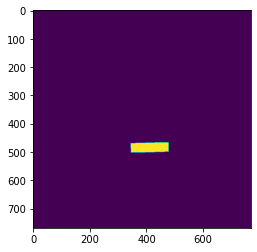

In [28]:
plt.imshow(mask)

In [29]:
ra1 = ra.copy()
ra1[mask==1, :] = [0, 255, 255]

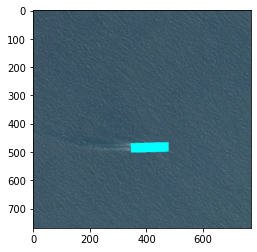

In [30]:
plt.imshow(ra1)

### Ground truth segmented bounding box 

In [ ]:
img = cv2.imread("../input/iwildcam2021-fgvc8/train/"+image)

In [426]:
def parse_label(ind):
    rand_ind = positive_samples_ind[ind]
    #filename = markup.iloc[rand_ind].ImageId
    pixels = markup.iloc[rand_ind].EncodedPixels
    #randimage = cv2.imread(os.path.join(train_path, filename))
    li = pixels.split(' ')
    coord_intens = [(int(li[i]), int(li[i+1])) for i in range(0, len(li)-1, 2)]
    mask = np.zeros(randimage.shape[:-1:])
    points = []
    points_x = []
    for i, (coord, intens) in enumerate(coord_intens):
    
        y = coord//randimage.shape[0]
        x = coord%randimage.shape[0]
        points.append((x, y))
        mask[x:x+intens, y:y+intens] = 1
    return mask

def count_pixels(ind, randimage_shape = (768,768)):
    pixels = markup.iloc[rand_ind].EncodedPixels
    li = pixels.split(' ')
    coord_intens = [(int(li[i]), int(li[i+1])) for i in range(0, len(li)-1, 2)]
    mask = np.zeros(randimage_shape)
    for i, (coord, intens) in enumerate(coord_intens):
        y = coord//ra.shape[0]
        x = coord%ra.shape[0]
        mask[x:x+intens, y:y+intens] = 1
    return mask.mean()


In [ ]:

mean = 0
for i,_ in enumerate(positive_samples_ind):
    mean += count_pixels(i)
    print(i)

In [441]:
mean/(len(positive_samples_ind)+len(negative_samples_ind))

0.002697276977593624

### We will use this number to balance loss function later, we have 0.27% of positive pixels, other are negative

In [31]:
markup.iloc[0].ImageId

'00003e153.jpg'

In [32]:
annotpath = './annotations/'
Path(annotpath).mkdir(parents=True, exist_ok=True)


### Write masks to images

In [164]:
def write_label(ind, annot_folder, img_size=(768, 768)):
    #rand_ind = positive_samples_ind[ind]
    filename = markup.iloc[ind].ImageId
    pixels = markup.iloc[ind].EncodedPixels
    print(str(pixels)=='nan')
    mask = np.zeros((*img_size, 3), dtype=float)
    if not str(pixels)=='nan':
        li = pixels.split(' ')
        coord_intens = [(int(li[i]), int(li[i+1])) for i in range(0, len(li)-1, 2)]

        for i, (coord, intens) in enumerate(coord_intens):

            y = coord//img_size[0]
            x = coord%img_size[0]
            mask[x:x+intens, y:y+intens] = 1.
    #print(mask.shape)
    
    Image.fromarray((mask * 255).astype(np.uint8)).save(os.path.join(annot_folder, filename))
    return mask

In [ ]:
for ind in markup.index:
    write_label(ind, annotpath)
    print(ind)

In [33]:
train_path, annotpath


('./train_v2/', './annotations/')

In [35]:
train_imgs = glob.glob('.\\train_v2\\*.jpg')
train_annots = glob.glob('.\\annotations\\*.jpg')

In [36]:
traing_imgs = np.sort(train_imgs)
train_annots = np.sort(train_annots)

In [37]:
traing_imgs[:5], train_annots[:5]

(array(['.\\train_v2\\00003e153.jpg', '.\\train_v2\\0001124c7.jpg',
        '.\\train_v2\\000155de5.jpg', '.\\train_v2\\000194a2d.jpg',
        '.\\train_v2\\0001b1832.jpg'], dtype='<U24'),
 array(['.\\annotations\\00003e153.jpg', '.\\annotations\\0001124c7.jpg',
        '.\\annotations\\000155de5.jpg', '.\\annotations\\000194a2d.jpg',
        '.\\annotations\\0001b1832.jpg'], dtype='<U27'))

In [41]:
import keras
import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io
import tensorflow as tf
import random
import datetime
import math

In [42]:
def parse_label(encmask, img_size=(768, 768)):
    mask = np.zeros(img_size)
    if encmask == 'Nan':
        return mask
    print(tf.get_static_value(encmask, partial=False), encmask)
    li = tf.get_static_value(encmask, partial=False).split(' ')
    coord_intens = [(int(li[i]), int(li[i+1])) for i in range(0, len(li)-1, 2)]
    points = []
    points_x = []
    for i, (coord, intens) in enumerate(coord_intens):
    
        y = coord//img_size[0]
        x = coord%img_size[0]
        points.append((x, y))
        mask[x:x+intens, y:y+intens] = 1
    return mask

In [127]:
def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, input_target_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_jpeg(input_img, channels=3)
        #input_img = tf_image.resize(input_img, img_size)
        input_img = tf_image.convert_image_dtype(input_img, "float")

        target_img = tf_io.read_file(input_target_path)
        target_img = tf_io.decode_jpeg(target_img, channels=1)
        #target_img = tf_image.resize(target_img, img_size)    
        target_img = tf_image.convert_image_dtype(target_img, "float")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        #target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    #markup = markup.to_numpy()
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)


In [128]:
from keras import layers

In [129]:
def get_model(img_size, num_classes):
    inputs = keras.Input(shape = (*img_size,3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    prev_block_activation = x
    
    for filters in [64,128,256]:
        x = layers.Activation('relu')(x)
        x = layers.SeparableConv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Activation('relu')(x)
        x = layers.SeparableConv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.MaxPooling2D(3, strides=2,padding='same')(x)
        
        residual = layers.Conv2D(filters, 1, strides=2,padding='same')(
            prev_block_activation
        )
        
        x = layers.add([residual, x])
        prev_block_activation = x
    
    for filters in [256,128,64,32]:
        x = layers.Activation('relu')(x)
        x = layers.Conv2DTranspose(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Activation('relu')(x)
        x = layers.Conv2DTranspose(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.UpSampling2D(2)(x)
        
        residual = layers.UpSampling2D(2)(prev_block_activation)
        
        residual = layers.Conv2D(filters, 1, padding="same")(residual)
        x = layers.add([residual, x])
        
        prev_block_activation = x
    
    outputs = layers.Conv2D(num_classes, 3, activation='softmax', padding='same')(x)
    
    model = keras.Model(inputs, outputs)
    return model
    

In [130]:
img_size=(768, 768)
num_classes = 2    
model = get_model(img_size, num_classes)

In [131]:
model.summary()

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 768, 768, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_81 (Conv2D)             (None, 384, 384, 32  896         ['input_10[0][0]']               
                                )                                                                 
                                                                                                  
 batch_normalization_135 (Batch  (None, 384, 384, 32  128        ['conv2d_81[0][0]']              
 Normalization)                 )                                                           

                                                                                                  
 conv2d_84 (Conv2D)             (None, 48, 48, 256)  33024       ['add_64[0][0]']                 
                                                                                                  
 max_pooling2d_29 (MaxPooling2D  (None, 48, 48, 256)  0          ['batch_normalization_141[0][0]']
 )                                                                                                
                                                                                                  
 add_65 (Add)                   (None, 48, 48, 256)  0           ['conv2d_84[0][0]',              
                                                                  'max_pooling2d_29[0][0]']       
                                                                                                  
 activation_142 (Activation)    (None, 48, 48, 256)  0           ['add_65[0][0]']                 
          

 Normalization)                 )                                                                 
                                                                                                  
 conv2d_87 (Conv2D)             (None, 384, 384, 64  8256        ['up_sampling2d_77[0][0]']       
                                )                                                                 
                                                                                                  
 up_sampling2d_76 (UpSampling2D  (None, 384, 384, 64  0          ['batch_normalization_147[0][0]']
 )                              )                                                                 
                                                                                                  
 add_68 (Add)                   (None, 384, 384, 64  0           ['conv2d_87[0][0]',              
                                )                                 'up_sampling2d_76[0][0]']       
          

In [617]:
seed = 42
percentages= [0.8]# 10]#, 15, 20]
ns_epochs = [8]#, 10]
sample_weight=[2, 998]
img_size=(768, 768)
batch_size = 1

In [494]:
traing_imgs = np.sort(train_imgs)
train_annots = np.sort(train_annots)

In [495]:
traing_imgs[:5], train_annots[:5]

(array(['.\\train_v2\\00003e153.jpg', '.\\train_v2\\0001124c7.jpg',
        '.\\train_v2\\000155de5.jpg', '.\\train_v2\\000194a2d.jpg',
        '.\\train_v2\\0001b1832.jpg'], dtype='<U24'),
 array(['.\\annotations\\00003e153.jpg', '.\\annotations\\0001124c7.jpg',
        '.\\annotations\\000155de5.jpg', '.\\annotations\\000194a2d.jpg',
        '.\\annotations\\0001b1832.jpg'], dtype='<U27'))

In [563]:
val_inds = random.sample(range(len(traing_imgs)), len(traing_imgs)//100*5)

In [564]:
train_inds = random.sample(list(set(range(len(traing_imgs))).difference(set(val_inds))), len(traing_imgs)//100*5)

In [566]:
len(train_inds)

9625

### Simple probabilistic choice without return

In [606]:
n_samples = 2000
train_inds_copy = train_inds[:]
samples = dict()
pi = n_samples/len(train_inds_copy)
a = len(train_inds_copy)/n_samples
r = np.random.uniform(low=0.0, high=a, size=None)

In [607]:
samples['simple probabilistic'] = np.random.choice(train_inds_copy, size=n_samples, replace = False)

In [608]:
samples['bernoulli'] = np.asarray(train_inds_copy)[np.random.rand(len(train_inds_copy))<=pi]

In [609]:
samples['systematic'] = np.asarray(train_inds_copy)[np.ceil(np.arange(r,  len(train_inds_copy)-1, a)).astype(int)]

In [610]:
samples['bernoulli'].shape,samples['simple probabilistic'].shape, samples['systematic'].shape

((1935,), (2000,), (2000,))

In [628]:
gpus = tf.config.list_logical_devices('GPU')

In [629]:
cpus = tf.config.list_logical_devices('CPU')

In [620]:
for name, inds in samples.items():
    X_train = list(np.asarray(train_imgs)[inds])
    y_train = list(np.asarray(train_annots)[inds])
    X_val = list(np.asarray(train_imgs)[val_inds])
    y_val = list(np.asarray(train_annots)[val_inds])
    train_dataset = get_dataset(
        batch_size=batch_size,
        img_size=img_size,
        input_img_paths = X_train,
        target_img_paths = y_train,
        max_dataset_len=None#1000,
    )
    valid_dataset = get_dataset(
        batch_size=batch_size,
        img_size=img_size,
        input_img_paths = X_val,
        target_img_paths = y_val,
        max_dataset_len=1000
    )
    n_batches = len(train_dataset) / batch_size
    n_batches = math.ceil(n_batches)
    gpus = tf.config.list_logical_devices('GPU')
    for percentage in percentages:
        for n_epochs in ns_epochs:
            model = get_model(img_size, num_classes)

            log_dir_tb = f"tb_logs/data_{name}_{percentage}%_{n_epochs}epochs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            model_dir = f"models/data_{name}_{percentage}%_{n_epochs}epochs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") + "cp-{epoch:04d}.ckpt"
            checkpoint_dir = os.path.dirname(model_dir)
            log_dir_sw = f"sw_logs/data_{name}_{percentage}%_{n_epochs}epochs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

            cp_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=model_dir, 
            verbose=1, 
            save_weights_only=True,
            save_freq=n_epochs*n_batches)

            tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir_tb, histogram_freq=1)


            model.compile(
                optimizer=keras.optimizers.Adam(1e-7),
                loss=keras.losses.SparseCategoricalCrossentropy(),
                loss_weights=sample_weight
            )
            model.save_weights(model_dir.format(epoch=0))
            with tf.device(gpus[0].name):
                model.fit(train_dataset,
                          validation_data=valid_dataset,
                          verbose=1,
                          callbacks=[tensorboard_callback, cp_callback],
                          epochs=n_epochs)


Epoch 1/8
2000/2000 [==============================] - 410s 203ms/step - loss: 5.4618 - val_loss: 15.0326
Epoch 2/8
2000/2000 [==============================] - 421s 210ms/step - loss: 1.2636 - val_loss: 3.1682
Epoch 3/8
2000/2000 [==============================] - 424s 212ms/step - loss: 0.3562 - val_loss: 1.3683
Epoch 4/8
2000/2000 [==============================] - 424s 212ms/step - loss: 0.1549 - val_loss: 0.8805
Epoch 5/8
1999/2000 [============================>.] - ETA: 0s - loss: 0.0989
Epoch 5: saving model to models/data_simple probabilistic_0.8%_8epochs/fit\20240221-194527cp-0005.ckpt
2000/2000 [==============================] - 426s 213ms/step - loss: 0.0989 - val_loss: 0.7190
Epoch 6/8
2000/2000 [==============================] - 425s 212ms/step - loss: 0.0788 - val_loss: 0.6684
Epoch 7/8
2000/2000 [==============================] - 431s 215ms/step - loss: 0.0695 - val_loss: 0.6518
Epoch 8/8
2000/2000 [==============================] - 432s 216ms/step - loss: 0.0641 - val_l

## SIMPLE PROBABILISTIC WITHOUT REPLACEMENT

In [621]:
checkpoint_dir_simple_prob = f"models/data_simple probabilistic_0.8%_8epochs/fit/"

In [622]:
latest_simple_prob = tf.train.latest_checkpoint(checkpoint_dir_simple_prob)

model_simple_prob = get_model(img_size, num_classes)

# Load the previously saved weights
model_simple_prob.load_weights(latest)

In [623]:
X_val = list(np.asarray(train_imgs)[val_inds])
y_val = list(np.asarray(train_annots)[val_inds])

In [624]:
valid_dataset = get_dataset(
        batch_size=batch_size,
        img_size=img_size,
        input_img_paths = X_val,
        target_img_paths = y_val,
        max_dataset_len=1000
    )

In [630]:
cpus

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]

In [631]:
with tf.device(cpus[0].name):
    res_simple_prob = model_simple_prob.predict(valid_dataset)

1000/1000 [==============================] - 853s 853ms/step


In [632]:
res_simple_prob.shape

(1000, 768, 768, 2)

In [ ]:
res_simple_prob

In [633]:
y_simple_prob = np.concatenate([y for x, y in valid_dataset], axis=0)

In [638]:
y_simple_prob.ravel().shape

(589824000,)

In [652]:
y_simple_prob[y_simple_prob>=0.5]=1
y_simple_prob[y_simple_prob<0.5]=0

In [653]:
np.unique(y_simple_prob, return_counts=True)

(array([0., 1.], dtype=float32), array([588985138,    838862], dtype=int64))

In [635]:
res_simple_prob1 = torch.argmax(torch.Tensor(res_simple_prob), dim=-1).numpy()

In [637]:
res_simple_prob1.ravel().shape

(589824000,)

In [641]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd

In [642]:
classes = ('unmasked pixel', 'masked pixel')


In [663]:
ysp0 = y_simple_prob.ravel()

In [664]:
sample_weight = np.zeros(ysp0.shape)

In [668]:
sample_weight[ysp0==0] = 0.002
sample_weight[ysp0==1] = 0.998


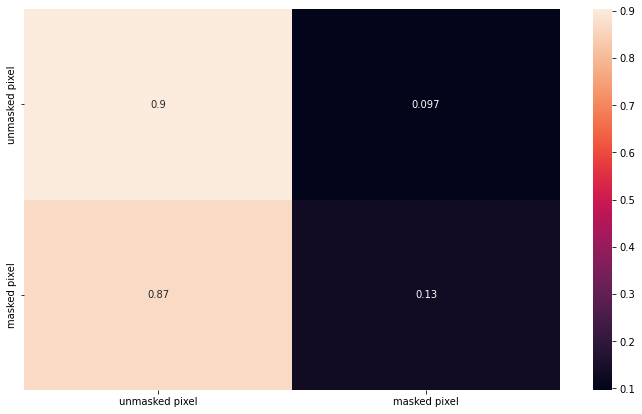

In [669]:
cf_matrix = confusion_matrix(y_simple_prob.ravel().astype(int), res_simple_prob1.ravel().astype(int), sample_weight=sample_weight,)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')

## BERNOULLI

In [655]:
checkpoint_dir_simple_prob = f"models/data_bernoulli_0.8%_8epochs/fit/"

In [656]:
latest_simple_prob = tf.train.latest_checkpoint(checkpoint_dir_simple_prob)

model_simple_prob = get_model(img_size, num_classes)

# Load the previously saved weights
model_simple_prob.load_weights(latest)

In [657]:
with tf.device(cpus[0].name):
    res_simple_prob = model_simple_prob.predict(valid_dataset)

1000/1000 [==============================] - 964s 963ms/step


In [658]:
res_simple_prob1 = torch.argmax(torch.Tensor(res_simple_prob), dim=-1).numpy()

In [659]:
classes = ('unmasked pixel', 'masked pixel')


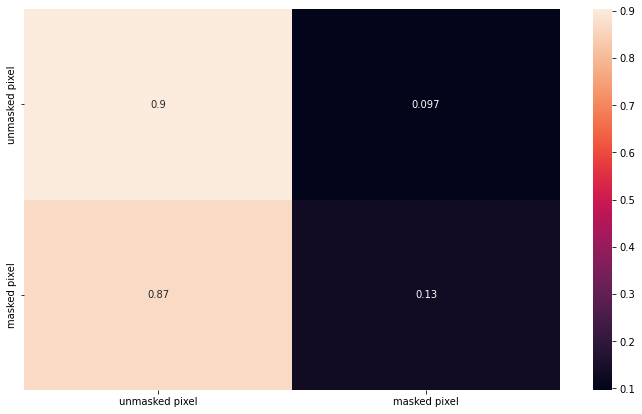

In [660]:
cf_matrix = confusion_matrix(y_simple_prob.ravel().astype(int), res_simple_prob1.ravel().astype(int), sample_weight=[0.002, 0.998],)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output_bernoulli.png')

In [670]:
cf_matrix

array([[1063702.49858653,  114267.76984508],
       [ 726519.05000938,  110665.22600029]])

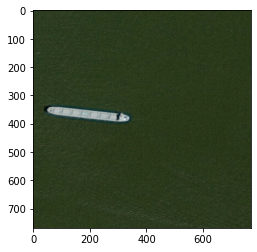

In [561]:
plt.imshow(x_test)

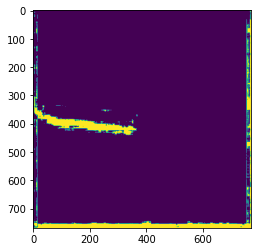

In [562]:
plt.imshow(tens[0])